# Edge IIoT - Anomaly Detection - Autoencoder

## 0. Imports

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report,
    confusion_matrix, precision_score, recall_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.preprocessing import Utils, Resamplers, Filters
from src.config import DATASETS, SEED

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

Device : cuda


---
## 1. Data Loading

In [2]:
dataset_name = 'edge_iiot'
config       = DATASETS[dataset_name]

filename = 'DL-EdgeIIoT-dataset_clean'
csv_path = config['processed_path'] / f'{filename}.pkl'

print('Loading dataset...')
df = pd.read_pickle(csv_path)
print(f'Dataset shape : {df.shape}')

Loading dataset...
Dataset shape : (2158750, 62)


---
## 2. Pre-processing 

In [3]:
cols_to_drop = [
    'frame.time.delta', 'frame.time.order',
    *[c for c in df.columns if c.startswith('ip.src_category') or c.startswith('ip.dst_category')]
]
df = df.drop(columns=cols_to_drop, errors='ignore')

In [4]:
from sklearn.pipeline import Pipeline

preprocessing_pipeline = Pipeline([
    ("filter_invalid_time", Filters.ValidTimeFilter()),
    ("drop_categorical",    Filters.CategoricalDropper()),
    ("train_test_split",    Utils.AnomalyTrainTestSplitter()),
    ('xysplit',             Utils.SplitExtractor())
])

X_train, X_test, y_train, y_test, _, y_mc_test, X_val, y_val, _  = preprocessing_pipeline.fit_transform(df)


  [ValidTimeFilter] Dropped 122,596 rows  →  (2036154, 52)
  [CategoricalDropper] Dropped 7 categorical columns: ['http.file_data', 'http.referer', 'http.request.path', 'http.request.uri.query', 'http.request.version', 'mqtt.msg', 'proto']  →  (2036154, 45)
  [AnomalyTrainTestSplitter]
    Train: 1,130,949 (Normal only)
    Val:   301,734 (161,564 Normal + 140,170 attacks)
    Test:  603,471 (323,129 Normal + 280,342 attacks)
  [SplitExtractor] X_train: (1130949, 43)  |  X_test: (603471, 43)  |  y_bin_train: (1130949,) | y_15c_train: (1130949,) | y_bin_test: (603471,) | y_15c_test: (603471,)
  [SplitExtractor] X_val: (301734, 43) | y_bin_val: (301734,) | y_15c_val: (301734,)


In [5]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'Train scaled : {X_train_scaled.shape}')
print(f'Val   scaled : {X_val_scaled.shape}'  )
print(f'Test  scaled : {X_test_scaled.shape}' )

Train scaled : (1130949, 43)
Val   scaled : (301734, 43)
Test  scaled : (603471, 43)


In [6]:
actual_rate = (y_train == 1).mean()
print(f"Attack rate in training pool:{actual_rate*100:.2f}%")

Attack rate in training pool:0.00%


---
## 3. Variational Autoencoder (VAE) Definition

### Threshold Function

In [7]:
def threshold_from_train_quantile(train_scores, q=0.95):
    return np.quantile(train_scores, q)

### Error Functions

In [8]:
from typing import Callable

def mse_error(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
    """Mean squared error per sample."""
    return ((x - recon) ** 2).mean(dim=1)


def mae_error(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
    """Mean absolute error per sample (L1). More robust to outlier features."""
    return (x - recon).abs().mean(dim=1)


def rmse_error(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
    """Root mean squared error per sample."""
    return ((x - recon) ** 2).mean(dim=1).sqrt()


def cosine_error(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
    """1 - cosine similarity per sample. Captures directional mismatch
    rather than magnitude; useful when feature scales vary."""
    return 1.0 - torch.cosine_similarity(x, recon, dim=1)


def smooth_l1_error(
    x: torch.Tensor, recon: torch.Tensor, beta: float = 1.0
) -> torch.Tensor:
    """Huber / smooth-L1 error per sample. Quadratic for small residuals,
    linear for large ones — a compromise between MSE and MAE."""
    return nn.functional.smooth_l1_loss(
        recon, x, reduction="none", beta=beta
    ).mean(dim=1)

In [9]:
ERROR_FUNCTIONS: dict[str, Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = {
    "mse": mse_error,
    "mae": mae_error,
    "rmse": rmse_error,
    "cosine": cosine_error,
    "smooth_l1": smooth_l1_error,
}

### Modular Architecture

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class VAE(nn.Module):
    """Variational autoencoder (MLP form)."""

    DEFAULT_EPS = 1e-8

    def __init__(
        self,
        input_dim: int,
        hidden_dims: tuple[int, ...] = (64, 32),
        latent_dim: int = 16,
        activation: type[nn.Module] = nn.ReLU,
        batch_norm: bool = True,
        use_softplus_std: bool = False,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.use_softplus_std = use_softplus_std

        # Encoder body: input_dim -> hidden_dims  (activation on every layer)
        encoder_dims = [input_dim, *hidden_dims]
        self.encoder = self._build_mlp(
            encoder_dims, activation, batch_norm, final_activation=True
        )
        # Project last hidden -> latent params (mu, sigma) concatenated
        self.to_latent = nn.Linear(encoder_dims[-1], latent_dim * 2)

        # Decoder: latent_dim -> reversed(hidden_dims) -> input_dim (logits, no final act)
        decoder_dims = [latent_dim, *reversed(hidden_dims), input_dim]
        self.decoder = self._build_mlp(
            decoder_dims, activation, batch_norm, final_activation=False
        )

    # ===============================================================================
    @staticmethod
    def _build_mlp(
        dims: list[int],
        activation: type[nn.Module],
        batch_norm: bool,
        final_activation: bool,
    ) -> nn.Sequential:
        """Construct an MLP from a list of layer dimensions."""
        layers: list[nn.Module] = []
        n_layers = len(dims) - 1
        for i in range(n_layers):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            is_last = i == n_layers - 1
            if not is_last or final_activation:
                if batch_norm:
                    layers.append(nn.BatchNorm1d(dims[i + 1]))
                layers.append(activation())
        return nn.Sequential(*layers)

    # ===============================================================================
    def _sigma_to_std(self, sigma: torch.Tensor, eps: float = DEFAULT_EPS) -> torch.Tensor:
        """Convert raw sigma parameter to standard deviation."""
        if self.use_softplus_std:
            return F.softplus(sigma) + eps
        return torch.exp(0.5 * sigma)  # sigma represents log-variance

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encode input to latent distribution parameters (mu, sigma)."""
        h = self.encoder(x)
        mu, sigma = torch.chunk(self.to_latent(h), 2, dim=-1)
        return mu, sigma

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode latent representation to reconstruction logits."""
        return self.decoder(z)

    def reparameterize(self, mu: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
        """Reparameterization trick for differentiable sampling."""
        return mu + std * torch.randn_like(std)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Stochastic reconstruction in [0,1]. Caches latent params for `loss`."""
        mu, sigma = self.encode(x)
        std = self._sigma_to_std(sigma)
        z = self.reparameterize(mu, std)
        x_logits = self.decode(z)
        self._cache = (mu, sigma, std, x_logits)  # used by loss()
        return torch.sigmoid(x_logits)

    # ===============================================================================
    def loss(self, x: torch.Tensor, eps: float = DEFAULT_EPS) -> torch.Tensor:
        """ELBO loss = BCE reconstruction (sum / batch) + analytical KL. Lower is better."""
        self.forward(x)                       # populates self._cache
        mu, sigma, std, x_logits = self._cache

        loss_recon = F.binary_cross_entropy_with_logits(
            x_logits, x, reduction="sum"
        ) / x.size(0)

        if self.use_softplus_std:
            kl = 0.5 * torch.sum(
                mu.pow(2) + std.pow(2) - 1 - torch.log(std.pow(2) + eps), dim=1
            )
        else:
            kl = 0.5 * torch.sum(mu.pow(2) + sigma.exp() - 1 - sigma, dim=1)

        return loss_recon + kl.mean()

    # ===============================================================================
    @torch.no_grad()
    def reconstruction_error(
        self,
        x: torch.Tensor,
        error_fn: str | Callable[[torch.Tensor, torch.Tensor], torch.Tensor] = "mse",
    ) -> torch.Tensor:
        """Per-sample anomaly score. Deterministic: reconstructs from mu (no sampling)."""
        if isinstance(error_fn, str):
            try:
                error_fn = ERROR_FUNCTIONS[error_fn]
            except KeyError:
                raise ValueError(
                    f"Unknown error_fn '{error_fn}'. "
                    f"Choose from {list(ERROR_FUNCTIONS)} or pass a callable."
                )
        self.eval()
        mu, _ = self.encode(x)
        recon = torch.sigmoid(self.decode(mu))
        return error_fn(x, recon)

### Training Function

In [11]:
def _train_step(model, batch, criterion, optimizer):
    """Performs one training step."""
    model.train()
    batch = batch.to(DEVICE) # To GPU if available
    optimizer.zero_grad() # Clear gradients

    loss = model.loss(batch)

    loss.backward() # Backward pass
    optimizer.step() # Update weights

    return loss.item()


def _run_epoch(model, dataloader, criterion, optimizer) -> float:
    """Runs a full training loop over all batches in a dataloader."""

    running_loss = 0.0
    
    for batch in dataloader:
        batch_x = batch[0] if isinstance(batch, (list, tuple)) else batch # Unpacks if (inputs, labels) format
        loss_val = _train_step(model, batch_x, criterion, optimizer) # Train step
        running_loss += loss_val * batch_x.size(0) # Sum batch loss to total loss
        
    return running_loss / len(dataloader.dataset)

In [12]:
def _evaluate(model, dataloader, criterion):
    """Evaluates the model returning the average loss."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            batch_x = batch[0] if isinstance(batch, (list, tuple)) else batch # Unpacks if (inputs, labels) format
            batch_x = batch_x.to(DEVICE)
            loss = model.loss(batch_x)
            total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(dataloader.dataset)

In [13]:
import copy

def _check_early_stopping(
    val_loss: float,
    best_val: float,
    epochs_no_improve: int,
    es_patience: int,
    es_min_delta: float,
    model: torch.nn.Module,
    restore_best: bool
) -> tuple[bool, float, int, dict | None]:
    """Evaluates validation progress to handle early stopping and weight snapshots."""
    improved = val_loss < best_val - es_min_delta
    best_state = None
    stop_training = False

    if improved:
        best_val = val_loss
        epochs_no_improve = 0
        if restore_best:
            best_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= es_patience:
        stop_training = True

    return stop_training, best_val, epochs_no_improve, best_state

In [14]:
def train_autoencoder(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    *,
    criterion: torch.nn.Module = nn.MSELoss(),
    epochs: int = 30,
    early_stopping: bool = True,
    es_patience: int = 5,
    es_min_delta: float = 1e-4,
    restore_best: bool = True,
    log_every: int = 5,
    verbose: bool = True,
):
    """Modular autoencoder training."""
    
    # ================================================================================
    # Init
    model.to(DEVICE)

    history = {"train_loss": [], "val_loss": []}
    best_val, best_epoch, overall_best_state = float("inf"), -1, None
    epochs_no_improve = 0

    if verbose:
        print(f"Training Autoencoder on {len(train_loader.dataset):,} samples...")

    t0 = time.time()

    # ================================================================================
    # Epoch Loop
    for epoch in range(epochs):
        # ----------------------------------------------------------------------------
        # Train + Eval
        epoch_train_loss = _run_epoch(model, train_loader, criterion, optimizer)
        epoch_val_loss = _evaluate(model, val_loader, criterion)
        
        scheduler.step(epoch_val_loss)
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

         # ----------------------------------------------------------------------------
        # Early Stopping Check
        stop_early, updated_best_val, epochs_no_improve, epoch_state = _check_early_stopping(
            epoch_val_loss, best_val, epochs_no_improve, 
            es_patience, es_min_delta, model, restore_best
        )
        
        if updated_best_val < best_val:
            best_val = updated_best_val
            best_epoch = epoch
            if epoch_state is not None:
                overall_best_state = epoch_state

         # ----------------------------------------------------------------------------
        # Give Info
        if verbose and epoch % log_every == 0:
            flag = "  *" if updated_best_val < best_val or epoch == best_epoch else ""
            print(f"  Epoch {epoch:3d}/{epochs} | Train: {epoch_train_loss:.6f} | Val: {epoch_val_loss:.6f}{flag}")

        if early_stopping and stop_early:
            if verbose:
                print(f"  Early stopping triggered at epoch {epoch}.")
            break

    # ================================================================================
    # Save best model and more info
    if restore_best and overall_best_state is not None:
        model.load_state_dict(overall_best_state)

    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val

    if verbose:
        print(f"  Completed in {time.time() - t0:.1f}s | Best Val Loss: {best_val:.6f}")

    return history

---
## 4. AE Experiments

### Dataloaders

In [15]:
X_ae_train   = torch.tensor(X_train_scaled, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_ae_train), batch_size=512, shuffle=True)

X_val_normal_scaled = X_val_scaled[y_val == 0]
X_ae_val = torch.tensor(X_val_normal_scaled, dtype=torch.float32)
val_loader = DataLoader(TensorDataset(X_ae_val), batch_size=512, shuffle=False)

### Exp function

In [16]:
from dataclasses import dataclass, field

@dataclass
class ExpConfig:
    """Configuration for one autoencoder experiment."""
    name: str
    hidden_dims: tuple[int, ...]
    latent_dim: int
    activation: type
    batch_norm: bool = True
    epochs: int = 20
    lr: float = 1e-3                    # Optimizer control
    weight_decay: float = 1e-5          # Optimizer control
    scheduler_patience: int = 3         # Scheduler control
    scheduler_factor: float = 0.5       # Scheduler control
    early_stopping: bool = True
    es_patience: int = 5
    es_min_delta: float = 1e-4
    restore_best: bool = True
    error_fns: tuple[str, ...] = ("mse",)
    threshold_fpr: float = 0.01
    seed: int = SEED
    verbose: bool = False


@dataclass
class ExpOutput:
    """Result bundle for one autoencoder experiment."""
    name: str
    hidden_dims: tuple[int, ...]
    latent_dim: int
    depth: int
    width: int
    train_time: float
    history: dict
    per_loss: dict
    model: torch.nn.Module


def run_ae_experiment(cfg: ExpConfig) -> ExpOutput:
    """Build, train and evaluate one autoencoder configuration."""
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

    # ================================================================================
    # Build model
    model = VAE(
        input_dim=X_train_scaled.shape[1],
        hidden_dims=tuple(cfg.hidden_dims),
        latent_dim=cfg.latent_dim,
        activation=cfg.activation,
        batch_norm=cfg.batch_norm,
    ).to(DEVICE)

    # ================================================================================
    # Create optimizer and scheduler (MODIFYME)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=cfg.scheduler_patience, factor=cfg.scheduler_factor
    )

    # ================================================================================
    # Training Pass (timed)
    t0 = time.time()
    history = train_autoencoder(
        model,
        train_loader,
        val_loader,
        optimizer,
        scheduler,
        criterion=nn.MSELoss(),
        epochs=cfg.epochs,
        early_stopping=cfg.early_stopping,
        es_patience=cfg.es_patience,
        es_min_delta=cfg.es_min_delta,
        restore_best=cfg.restore_best,
        verbose=cfg.verbose,
    )
    train_time = time.time() - t0

    # ================================================================================
    # Inference & Score Evaluation
    X_val_tensor  = X_ae_val.to(DEVICE)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)

    per_loss = {}
    for ef in cfg.error_fns:

        val_scores  = model.reconstruction_error(X_val_tensor,  error_fn=ef).cpu().numpy()
        test_scores = model.reconstruction_error(X_test_tensor, error_fn=ef).cpu().numpy()

        # ----------------------------------------------------------------------------
        # Threshold (MODIFYME)
        thr = threshold_from_train_quantile(val_scores, q=1.0 - cfg.threshold_fpr)
        val_fpr = float((val_scores >= thr).mean())

        # ----------------------------------------------------------------------------
        # Metrics
        auroc = roc_auc_score(y_test, test_scores)
        auprc = average_precision_score(y_test, test_scores)

        y_pred = (test_scores >= thr).astype(int)
        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        per_loss[ef] = dict(
            AUROC=auroc,
            AUPRC=auprc,
            F1=rep["1"]["f1-score"],
            Precision=rep["1"]["precision"],
            Recall=rep["1"]["recall"],
            threshold=float(thr),
            val_fpr=val_fpr,
            y_pred=y_pred,
        )

    # ================================================================================
    # End
    depth = len(cfg.hidden_dims) + 1
    width = max([*cfg.hidden_dims, cfg.latent_dim])

    return ExpOutput(
        name=cfg.name,
        hidden_dims=tuple(cfg.hidden_dims),
        latent_dim=cfg.latent_dim,
        depth=depth,
        width=width,
        train_time=train_time,
        history=history,
        per_loss=per_loss,
        model=model,
    )

### Configs (MODIFYME)

In [17]:
ARCH_CONFIGS = [
    # Best found
    dict(name="baseline",   hidden_dims=(32, 24, 16),      latent_dim=8),

    # Lattent dimension
    dict(name="latent4",    hidden_dims=(32, 24, 16),      latent_dim=4),
    dict(name="latent12",   hidden_dims=(32, 24, 16),      latent_dim=12),

    # Depth
    dict(name="shallower",  hidden_dims=(32, 16),          latent_dim=8),  # 3 layers
    dict(name="deeper",     hidden_dims=(32, 24, 16, 12),  latent_dim=8),  # 5 layers

    # Width
    #dict(name="steep",      hidden_dims=(28, 16, 12),      latent_dim=8),  # faster # Takes too long to train.
    dict(name="gentle",     hidden_dims=(32, 28, 24),      latent_dim=8),  # slower
]

ACTIVATION_CONFIGS = [
    dict(name="relu", activation=nn.ReLU),
    dict(name="leaky_relu", activation=nn.LeakyReLU),
    dict(name="elu", activation=nn.ELU),
    dict(name="tanh", activation=nn.Tanh),
]

# Error functions to compare at scoring time (defined in ERROR_FUNCTIONS).
EVAL_LOSSES = ["mse", "mae", "rmse", "cosine", "smooth_l1"]

SWEEP_EPOCHS  = 30      # upper bound. Early stopping usually ends sooner
THRESHOLD_FPR = 0.05    # target false-positive rate on normal traffic

### Execution

In [18]:
runs = {}

for act_cfg in ACTIVATION_CONFIGS:
    for arch_cfg in ARCH_CONFIGS:
        unique_run_name = f"{arch_cfg['name']}_{act_cfg['name']}"
        
        print(f"\n--- {unique_run_name} ---")
        
        # Executes the newly updated experiment function
        cfg = ExpConfig(
            name=arch_cfg["name"],
            hidden_dims=arch_cfg["hidden_dims"],
            latent_dim=arch_cfg["latent_dim"],
            activation=act_cfg["activation"],
            epochs=SWEEP_EPOCHS,
            early_stopping=True,
            es_patience=5,
            error_fns=EVAL_LOSSES,
            threshold_fpr=THRESHOLD_FPR,
            verbose=True,  # Will display the modular epoch output cleanly
        )
        run = run_ae_experiment(cfg)
        
        
        # Select best metric
        best_ef = max(run.per_loss.keys(), key=lambda ef: run.per_loss[ef]["AUPRC"])
        m = run.per_loss[best_ef]
        
        # Info about the run and best metric
        print(
            f"  depth={run.depth}  width={run.width}  "
            f"  [Best Metric: {best_ef}] -> "
            f"AUROC={m['AUROC']:.4f}  AUPRC={m['AUPRC']:.4f}  F1={m['F1']:.4f}  "
            f"Recall={m['Recall']:.4f}  val_FPR={m['val_fpr']:.3f}"
        )

        # Save results
        runs[unique_run_name] = run


--- baseline_relu ---
Training Autoencoder on 1,130,949 samples...
  Epoch   0/30 | Train: 4.080121 | Val: 2.520107  *
  Epoch   5/30 | Train: 2.366791 | Val: 2.345387  *
  Epoch  10/30 | Train: 2.352019 | Val: 2.339217
  Epoch  15/30 | Train: 2.346900 | Val: 2.341549
  Epoch  20/30 | Train: 2.346805 | Val: 2.321706  *
  Epoch  25/30 | Train: 2.339935 | Val: 2.325625
  Early stopping triggered at epoch 25.
  Completed in 482.3s | Best Val Loss: 2.321706
  depth=4  width=32    [Best Metric: mae] -> AUROC=0.7378  AUPRC=0.7974  F1=0.6208  Recall=0.4754  val_FPR=0.050

--- latent4_relu ---
Training Autoencoder on 1,130,949 samples...
  Epoch   0/30 | Train: 3.873384 | Val: 2.430623  *
  Epoch   5/30 | Train: 2.382058 | Val: 2.357533  *
  Epoch  10/30 | Train: 2.373831 | Val: 2.365496
  Epoch  15/30 | Train: 2.369531 | Val: 2.354814
  Epoch  20/30 | Train: 2.364104 | Val: 2.347327
  Early stopping triggered at epoch 21.
  Completed in 402.0s | Best Val Loss: 2.347198
  depth=4  width=32   

### Training Curves

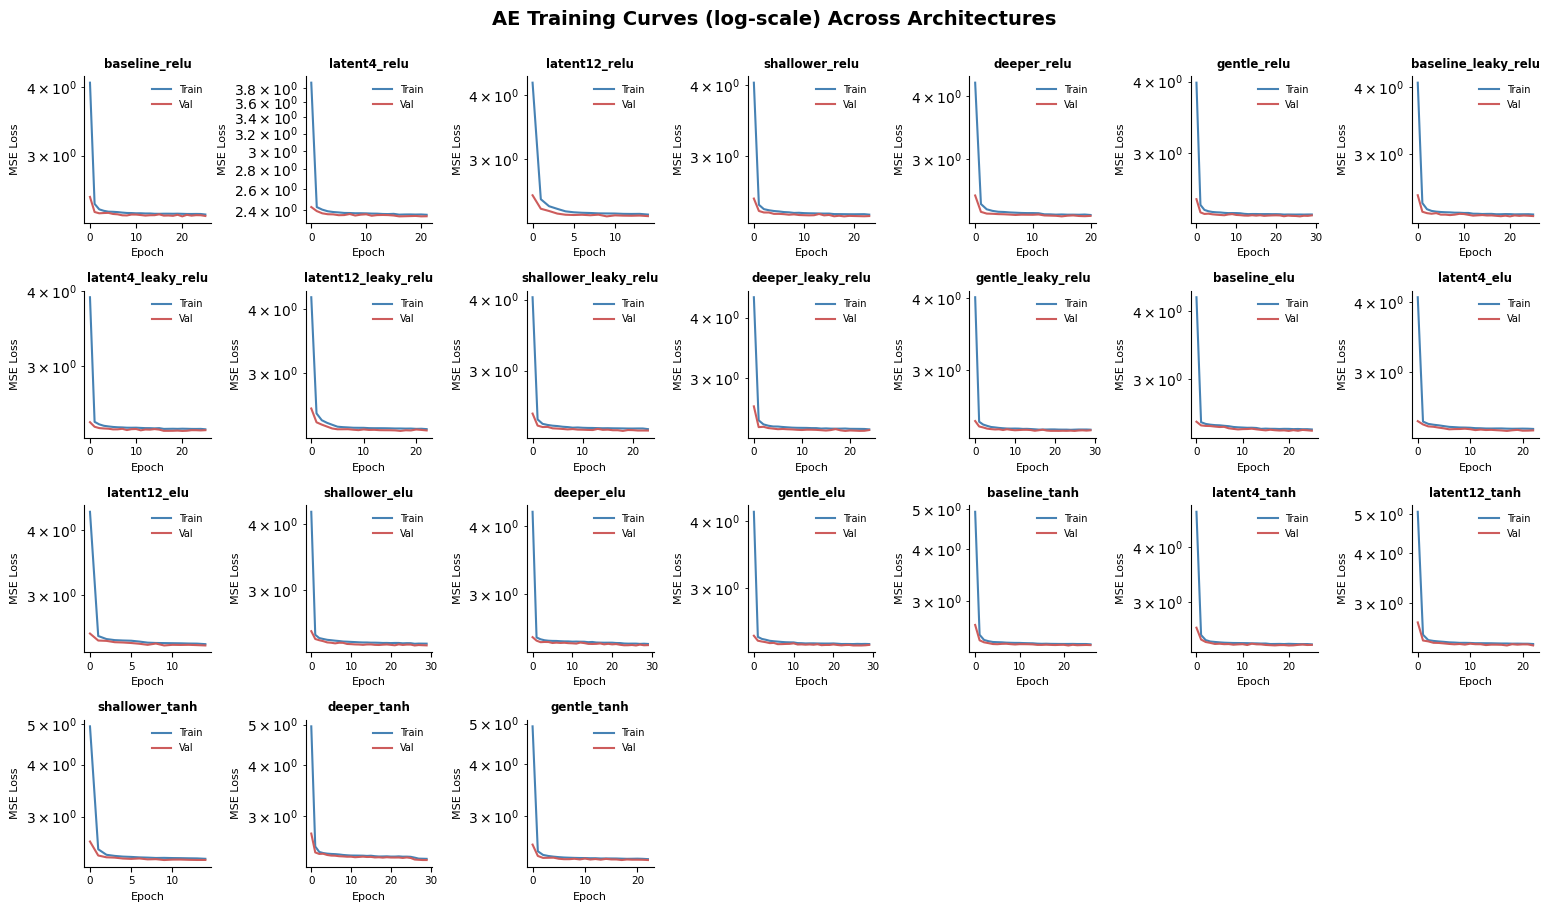

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

n_runs = len(runs)
ncols = 7
nrows = int(np.ceil(n_runs / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(2.2 * ncols, 2.2 * nrows), squeeze=False
)

for ax, (name, r) in zip(axes.flat, runs.items()):
    h = r.history
    ax.plot(h["train_loss"], color="steelblue", label="Train", linewidth=1.5)
    ax.plot(h["val_loss"], color="indianred", label="Val", linewidth=1.5)
    
    ax.set_title(name, fontsize=8.5, weight="semibold")
    ax.set_xlabel("Epoch", fontsize=8)
    ax.set_ylabel("MSE Loss", fontsize=8)
    ax.set_yscale("log")

    ax.tick_params(axis="both", labelsize=7.5)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    ax.legend(fontsize=7, frameon=True, facecolor="white", edgecolor="none")

for ax in axes.flat[n_runs:]:
    ax.set_visible(False)

fig.suptitle(
    "AE Training Curves (log-scale) Across Architectures",
    fontsize=14,
    y=1.02,
    weight="bold",
)
sns.despine(fig=fig)
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
plt.show()

---
## 5. Exp Comparison

In [20]:
parsed_data = []

for unique_run_name, run in runs.items():
    arch_name = run.name
    act_name = unique_run_name.replace(f"{arch_name}_", "")
    
    best_ef = max(run.per_loss.keys(), key=lambda ef: run.per_loss[ef]["AUPRC"])
    metrics = run.per_loss[best_ef]
    
    parsed_data.append({
        "Unique_Run": unique_run_name,
        "Architecture": arch_name,
        "Activation": act_name,
        "Best_Error_Fn": best_ef,
        "AUROC": metrics["AUROC"],
        "AUPRC": metrics["AUPRC"],
        "F1": metrics["F1"],
        "Recall": metrics["Recall"],
        "Val_FPR": metrics["val_fpr"],
        "Train_Time": run.train_time,
        "Best_Val_Loss": run.history["best_val_loss"],
        "Depth": run.depth,
        "Width": run.width
    })

# Convert to DataFrame
df_runs = pd.DataFrame(parsed_data)

### Architectures vs Activation

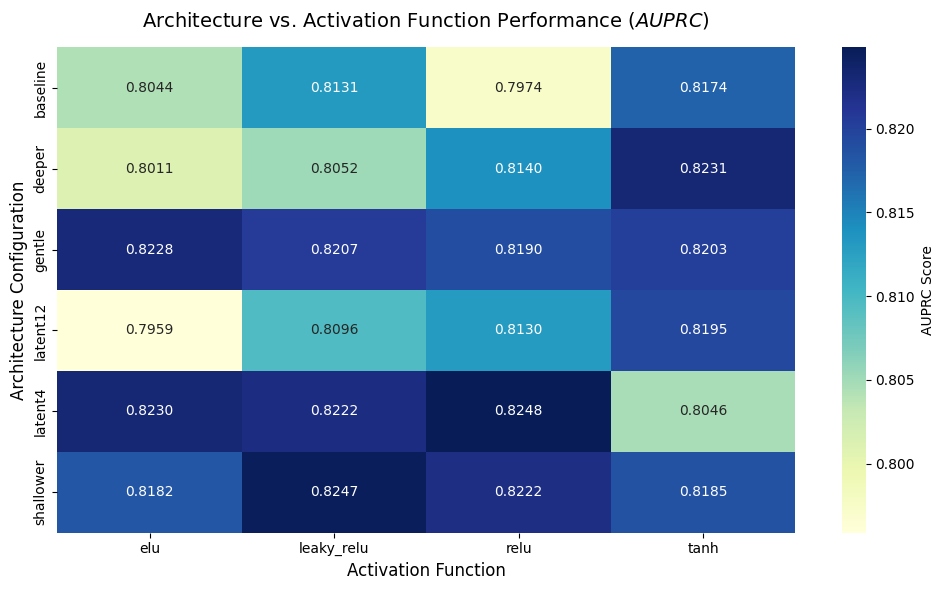

In [21]:
heatmap_matrix = df_runs.pivot(index="Architecture", columns="Activation", values="AUPRC")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_matrix, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={'label': 'AUPRC Score'})

plt.title("Architecture vs. Activation Function Performance ($AUPRC$)", fontsize=14, pad=15)
plt.ylabel("Architecture Configuration", fontsize=12)
plt.xlabel("Activation Function", fontsize=12)
plt.tight_layout()
plt.show()

### Performance vs Efficiency

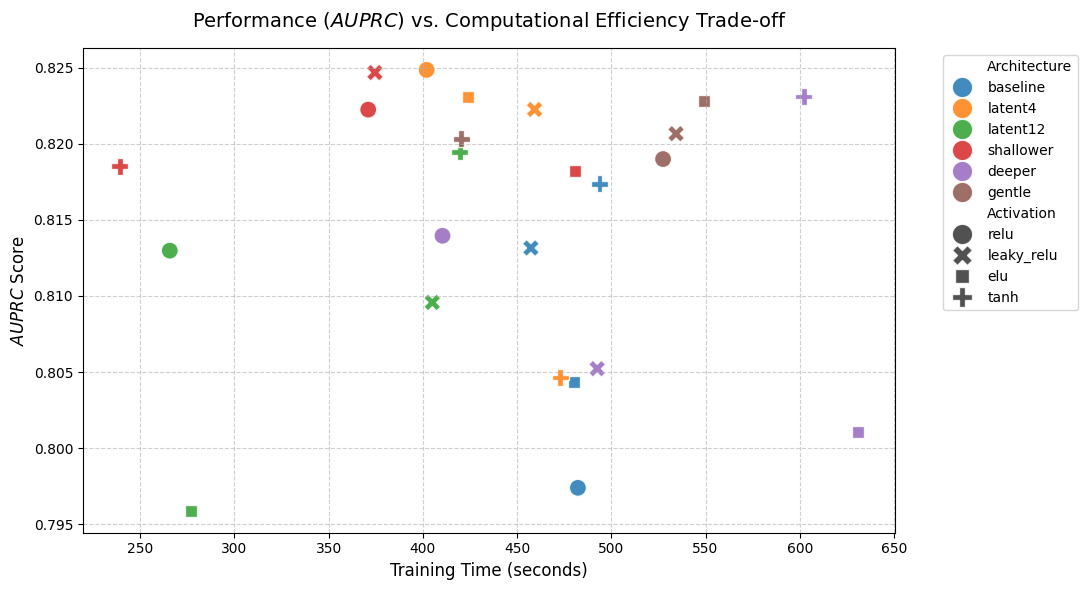

In [22]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df_runs, 
    x="Train_Time", 
    y="AUPRC", 
    hue="Architecture", 
    style="Activation", 
    s=150, 
    alpha=0.85
)

plt.title("Performance ($AUPRC$) vs. Computational Efficiency Trade-off", fontsize=14, pad=15)
plt.xlabel("Training Time (seconds)", fontsize=12)
plt.ylabel("$AUPRC$ Score", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

---
## 6. Best AE

In [23]:
BEST_ARCH = "latent4"
BEST_ACT = "leaky_relu"

In [24]:
best_run_data = runs[f"{BEST_ARCH}_{BEST_ACT}"]

# Iterate through all loss functions for this specific run to find the best AUROC
loss_records = []
for ef_name, metrics in best_run_data.per_loss.items():
    loss_records.append({
        "Error_Fn": ef_name,
        "AUROC": metrics["AUROC"],
        "AUPRC": metrics["AUPRC"],
        "F1": metrics["F1"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
    })

# Convert to a temporary DataFrame to easily locate the top performance metric
run_loss_df = pd.DataFrame(loss_records)
best_loss_idx = run_loss_df["AUROC"].idxmax()
best_loss_row = run_loss_df.loc[best_loss_idx]

best_loss_metrics = best_run_data.per_loss[best_loss_row["Error_Fn"]]
num_params = sum(p.numel() for p in best_run_data.model.parameters() if p.requires_grad)

# ==============================================================================
# Info
print(f"Configuration profile for: {BEST_ARCH.upper()}_{BEST_ACT.upper()}")
print(f"  Architecture  : {BEST_ARCH} + {BEST_ACT} "
      f"(hidden={best_run_data.hidden_dims}, latent={best_run_data.latent_dim})")
print(f"  Error fn      : {best_loss_row['Error_Fn']}")
print(f"  AUROC={best_loss_row['AUROC']:.4f}  AUPRC={best_loss_row['AUPRC']:.4f}")
print(f"  Operating point @ {THRESHOLD_FPR:.0%} target FPR "
      f"(normal-val FPR={best_loss_metrics['val_fpr']:.3f}, threshold={best_loss_metrics['threshold']:.4f}):")
print(f"    F1={best_loss_row['F1']:.4f}  Precision={best_loss_row['Precision']:.4f}  Recall={best_loss_row['Recall']:.4f}")
print(f"  Params        : {num_params:,}   "
      f"Train time: {best_run_data.train_time:.1f}s")

Configuration profile for: LATENT4_LEAKY_RELU
  Architecture  : latent4 + leaky_relu (hidden=(32, 24, 16), latent=4)
  Error fn      : cosine
  AUROC=0.8175  AUPRC=0.8222
  Operating point @ 5% target FPR (normal-val FPR=0.078, threshold=0.0354):
    F1=0.7064  Precision=0.8690  Recall=0.5951
  Params        : 5,731   Train time: 459.3s


### Confussion Matrixes per error function

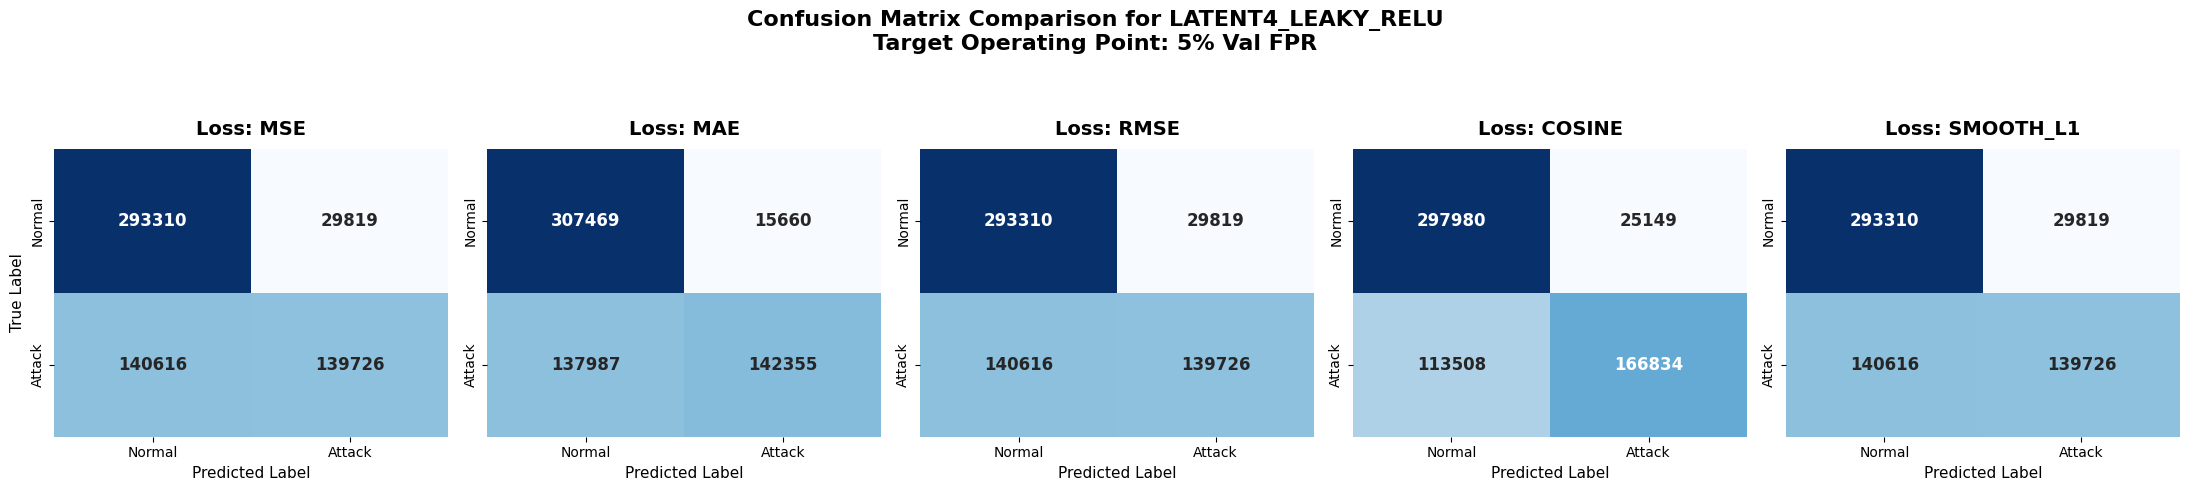

In [25]:
error_fns = list(best_run_data.per_loss.keys())
fig, axes = plt.subplots(1, len(error_fns), figsize=(22, 4.5))

for i, ef_name in enumerate(error_fns):
    ax = axes[i]
    y_pred = best_run_data.per_loss[ef_name]["y_pred"]
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        cbar=False, 
        ax=ax,
        annot_kws={"size": 12, "weight": "bold"},
        xticklabels=["Normal", "Attack"],
        yticklabels=["Normal", "Attack"]
    )
    
    # Formatting individual subplot
    ax.set_title(f"Loss: {ef_name.upper()}", fontsize=14, pad=10, weight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    if i == 0:
        ax.set_ylabel("True Label", fontsize=11)
    else:
        ax.set_ylabel("")

plt.suptitle(
    f"Confusion Matrix Comparison for {BEST_ARCH.upper()}_{BEST_ACT.upper()}\n"
    f"Target Operating Point: {THRESHOLD_FPR:.0%} Val FPR", 
    fontsize=16, 
    weight="bold", 
    y=1.08
)

plt.tight_layout()
plt.show()

### FPR (Precision vs Recall)

In [26]:
best_ef = max(best_run_data.per_loss.keys(),
              key=lambda ef: best_run_data.per_loss[ef]["AUROC"])

print(f"Best error function for {BEST_ARCH}_{BEST_ACT} is {best_ef.upper()} with AUROC={best_run_data.per_loss[best_ef]['AUROC']:.4f}")

Best error function for latent4_leaky_relu is COSINE with AUROC=0.8175


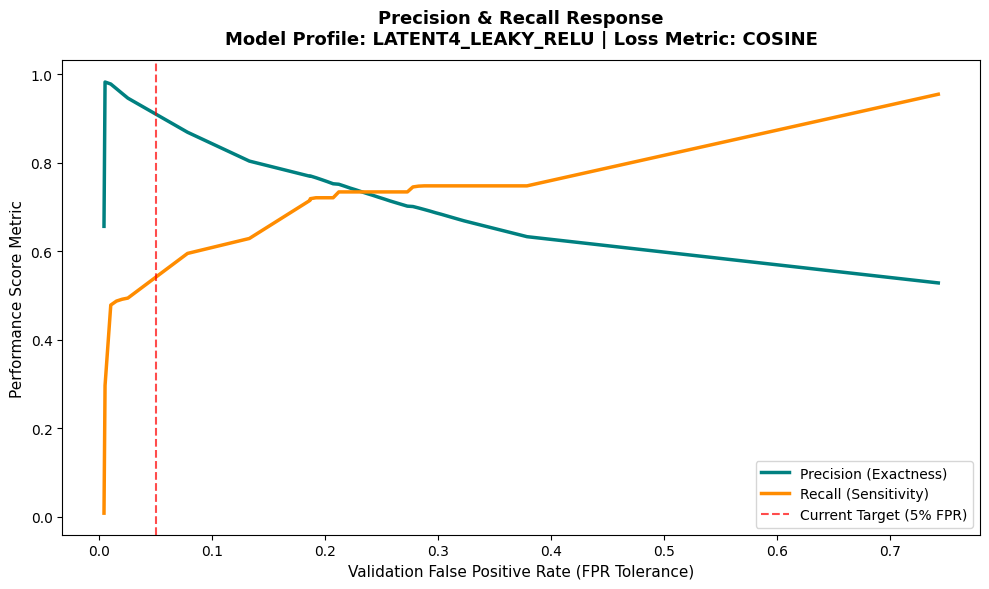

In [27]:
model = best_run_data.model

X_val_tensor = X_ae_val.to(DEVICE)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)

val_scores = model.reconstruction_error(X_val_tensor, error_fn=best_ef).cpu().numpy()
test_scores = model.reconstruction_error(X_test_tensor, error_fn=best_ef).cpu().numpy()

# ==============================================================================
# Calc
target_fpr_range = np.linspace(0.0, 0.50, 100)

precisions = []
recalls = []
actual_val_fprs = []

for fpr_target in target_fpr_range:
    q = 1.0 - fpr_target
    thr = np.quantile(val_scores, q) if q < 1.0 else np.max(val_scores)
    
    val_fpr = float((val_scores >= thr).mean())
    actual_val_fprs.append(val_fpr)
    y_pred = (test_scores >= thr).astype(int)
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))

idx_closest = np.abs(np.array(actual_val_fprs) - THRESHOLD_FPR).argmin()

# ==============================================================================
#  Plot
plt.figure(figsize=(10, 6))

# Curves
plt.plot(actual_val_fprs, precisions, label="Precision (Exactness)", color="teal", lw=2.5)
plt.plot(actual_val_fprs, recalls, label="Recall (Sensitivity)", color="darkorange", lw=2.5)

# Current
plt.axvline(
    x=THRESHOLD_FPR, 
    color="red", 
    linestyle="--", 
    alpha=0.7, 
    label=f"Current Target ({THRESHOLD_FPR:.0%} FPR)"
)

# Title & Labels
plt.title(
    f"Precision & Recall Response\n"
    f"Model Profile: {BEST_ARCH.upper()}_{BEST_ACT.upper()} | Loss Metric: {best_ef.upper()}", 
    fontsize=13, 
    pad=12, 
    weight="bold"
)
plt.xlabel("Validation False Positive Rate (FPR Tolerance)", fontsize=11)
plt.ylabel("Performance Score Metric", fontsize=11)

# Style
plt.legend(loc="best", frameon=True, facecolor="white")
plt.autoscale(enable=True, axis='both', tight=False)
plt.tight_layout()
plt.show()

### Per-class detection rate

In [28]:
y_pred_best = best_run_data.per_loss[best_ef]["y_pred"]
mc = np.asarray(y_mc_test)

# ==============================================================================
# Calc
rows = []
for cls in pd.unique(mc):
    mask = mc == cls
    n = int(mask.sum())
    is_attack = (y_test[mask] == 1).all()
    correct = y_pred_best[mask] == 1 if is_attack else y_pred_best[mask] == 0
    
    rows.append(dict(
        Class=str(cls),
        Kind="Attack" if is_attack else "Normal",
        Support=n,
        Detected=int((y_pred_best[mask] == 1).sum()),
        Accuracy=float(correct.mean()),
    ))

per_class_df = (
    pd.DataFrame(rows)
    .sort_values(["Kind", "Accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)

# ==============================================================================
# Print info
print(f"Per-class detection rate — best model: "
      f"{arch_name} + {act_name} / {best_ef} "
      f"(threshold @ {THRESHOLD_FPR:.0%} target FPR)\n")

print(per_class_df.to_string(index=False, float_format="{:.4f}".format))

print(f"\n  Macro (per-class mean) accuracy : {per_class_df['Accuracy'].mean():.4f}")
print(f"  Attack-only mean detection rate : "
      f"{per_class_df.loc[per_class_df['Kind']=='Attack','Accuracy'].mean():.4f}")

Per-class detection rate — best model: gentle + tanh / cosine (threshold @ 5% target FPR)

                Class   Kind  Support  Detected  Accuracy
            DDoS_ICMP Attack    51428     51428    1.0000
             DDoS_TCP Attack    19424     19424    1.0000
        Port_Scanning Attack    15015     15015    1.0000
       Fingerprinting Attack      692       692    1.0000
Vulnerability_scanner Attack    33371     28506    0.8542
            DDoS_HTTP Attack    33252     17859    0.5371
            Uploading Attack    25155     11482    0.4565
                  XSS Attack    10554      2957    0.2802
        SQL_injection Attack    33967      8779    0.2585
             Password Attack    33585      7507    0.2235
           Ransomware Attack     7269      1536    0.2113
             Backdoor Attack    16630      1649    0.0992
               Normal Normal   323129     25149    0.9222

  Macro (per-class mean) accuracy : 0.6033
  Attack-only mean detection rate : 0.5767


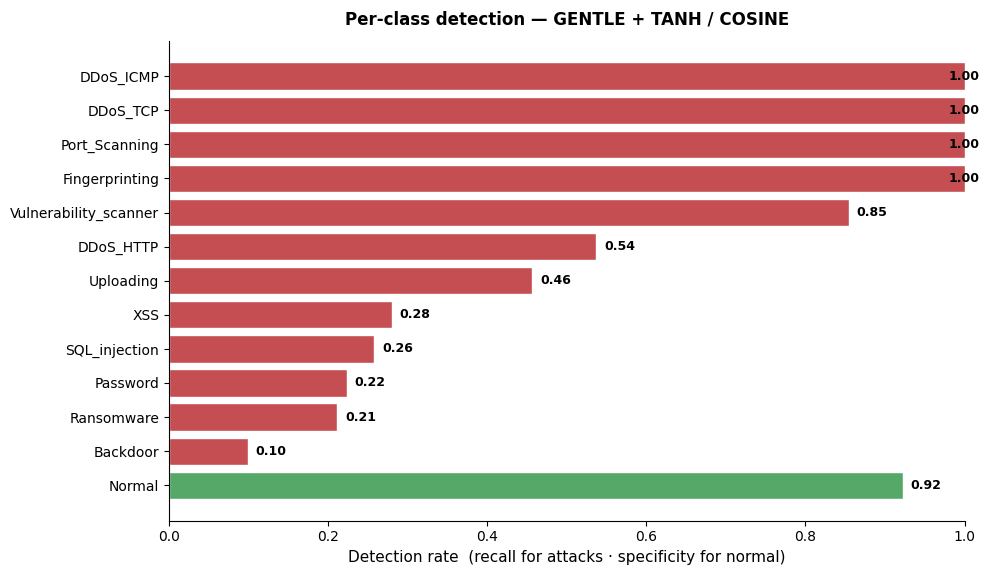

In [29]:
fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * len(per_class_df))))

# Lines
colors = ["#55A868" if k == "Normal" else "#C44E52" for k in per_class_df["Kind"]]
ax.barh(per_class_df["Class"], per_class_df["Accuracy"], color=colors, edgecolor="white")
ax.set_xlim(0, 1)
ax.invert_yaxis()

# Axis
ax.set_xlabel("Detection rate  (recall for attacks · specificity for normal)", fontsize=11)
ax.set_title(f"Per-class detection — {arch_name.upper()} + {act_name.upper()} / {best_ef.upper()}", 
             fontsize=12, pad=12, weight="bold")

# Numbers
for y, v in enumerate(per_class_df["Accuracy"]):
    ax.text(min(v + 0.01, 0.98), y, f"{v:.2f}", va="center", fontsize=9, weight="bold")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Save Model

In [30]:
import json
import joblib
from pathlib import Path

model_name = f"VAE_num_{BEST_ARCH}_{BEST_ACT}"

model_path = config['bin_model_path'] / 'exp4'
model_path.mkdir(parents=True, exist_ok=True)

best_model = best_run_data.model

# 
best_ef = max(best_run_data.per_loss.keys(),
              key=lambda ef: best_run_data.per_loss[ef]["AUROC"])
best_metrics = best_run_data.per_loss[best_ef]

# Inference config
inference_cfg = dict(
    run_name=f"{BEST_ARCH}_{BEST_ACT}",
    error_fn=best_ef,
    threshold=float(best_metrics["threshold"]),
    threshold_fpr=float(THRESHOLD_FPR),
    val_fpr=float(best_metrics["val_fpr"]),
    metrics={k: float(best_metrics[k])
             for k in ("AUROC", "AUPRC", "F1", "Precision", "Recall")},
)

# ------------------------------------------------------------------------------
# Quantization

torch.save(best_model.state_dict(), model_path / f"{model_name}_weights.pth")


# ------------------------------------------------------------------------------
# Hyperparameters (to rebuild the VAE before loading weights)
arch = dict(
    input_dim=best_model.input_dim,
    hidden_dims=list(best_run_data.hidden_dims),
    latent_dim=best_run_data.latent_dim,
    activation=type(best_model.encoder[-1]).__name__,  # e.g. "Tanh"
    use_softplus_std=best_model.use_softplus_std,
)

# 5. Everything non-binary in one JSON manifest
manifest = dict(architecture=arch, inference=inference_cfg)

with open(model_path / f"{model_name}_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved best VAE bundle to {model_path.resolve()}")
print(f"  Model      : {BEST_ARCH}_{BEST_ACT} "
      f"(hidden={arch['hidden_dims']}, latent={arch['latent_dim']}, act={arch['activation']})")
print(f"  Error fn   : {best_ef}")
print(f"  Threshold  : {inference_cfg['threshold']:.6f} @ {THRESHOLD_FPR:.0%} target FPR")
print(f"  Files      : {[p.name for p in sorted(model_path.iterdir())]}")

Saved best VAE bundle to C:\Users\angel\Documents\ML-NIDS-IIoT\models\edge_iiot\binary\exp4
  Model      : latent4_leaky_relu (hidden=[32, 24, 16], latent=4, act=LeakyReLU)
  Error fn   : cosine
  Threshold  : 0.035427 @ 5% target FPR
  Files      : ['VAE_num_latent4_leaky_relu_manifest.json', 'VAE_num_latent4_leaky_relu_scaler.joblib', 'VAE_num_latent4_leaky_relu_weights.pth', 'VAE_num_latent4_leaky_relu_weights_quantized.pth']
